# Figure 2 recreation

This notebook recreates Figure 2 from `project_background/RPM v2.pdf` in two forms:

1. the original light, paper-styled figure; and
2. the same figure on a black background using the animation palette and Optimistic font.

The time-series paths and confidence polygons are read directly from the vector objects embedded in the supplied PDF. The right-hand values and 95% confidence intervals are likewise taken from that vector figure, so both renderings share the source figure's geometry and data rather than an approximation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
import mpltex
import numpy as np
from pypdf import PdfReader
from pypdf.generic import ContentStream


def find_project_root():
    candidates = (Path.cwd(), Path.cwd().parent)
    for candidate in candidates:
        if (candidate / 'project_background' / 'RPM v2.pdf').exists():
            return candidate.resolve()
    raise FileNotFoundError('Could not locate project_background/RPM v2.pdf')


ROOT = find_project_root()
PAPER = ROOT / 'project_background' / 'RPM v2.pdf'
OUTPUT_DIR = ROOT / 'graphs'
OUTPUT_DIR.mkdir(exist_ok=True)

OPTIMISTIC_REGULAR = Path('/Library/Fonts/OptimisticV5_Regular.ttf')
OPTIMISTIC_BOLD = Path('/Library/Fonts/OptimisticV5_Bold.ttf')
for font_path in (OPTIMISTIC_REGULAR, OPTIMISTIC_BOLD):
    if font_path.exists():
        font_manager.fontManager.addfont(font_path)

VIDEO_FONT = (
    font_manager.FontProperties(fname=OPTIMISTIC_REGULAR).get_name()
    if OPTIMISTIC_REGULAR.exists()
    else 'DejaVu Sans'
)

print(f'Paper: {PAPER}')
print(f'Dark-theme font: {VIDEO_FONT}')

Paper: /Users/balomari/projects/RPMs/animation/project_background/RPM v2.pdf
Dark-theme font: Optimistic


In [2]:
SERIES = (
    'Agentic RPM',
    'Inference-only RPM',
    'No RPM',
    'Oracle (Test)',
    'Oracle (Validation)',
)

# Exact colors encoded in the paper's vector Figure 2.
PAPER_COLORS = {
    'Agentic RPM': '#75A366',
    'Inference-only RPM': '#F29040',
    'No RPM': '#E6C060',
    'Oracle (Test)': '#264653',
    'Oracle (Validation)': '#2A9D8F',
}

# Video palette with subdued neutral extensions for the baseline and oracles.
VIDEO_COLORS = {
    'Agentic RPM': '#47A5FA',
    'Inference-only RPM': '#F29040',
    'No RPM': '#7C8792',
    'Oracle (Test)': '#D6DADE',
    'Oracle (Validation)': '#89949F',
}

PAPER_LEFT_LINESTYLES = {
    'Agentic RPM': '-',
    'Inference-only RPM': '-',
    'No RPM': (0, (7.4, 3.2)),
}

PAPER_LEFT_MARKERS = {name: None for name in SERIES}

VIDEO_LEFT_LINESTYLES = {
    'Agentic RPM': '-',
    'Inference-only RPM': '-',
    'No RPM': (0, (7.4, 3.2)),
}

VIDEO_LEFT_MARKERS = {
    'Agentic RPM': None,
    'Inference-only RPM': None,
    'No RPM': None,
    'Oracle (Test)': 'o',
    'Oracle (Validation)': 'x',
}

def painted_paths(form, reader):
    """Return painted vector paths from a PDF Form XObject."""
    paths = []
    current = []
    paint_operators = {'S', 's', 'f', 'f*', 'B', 'B*', 'b', 'b*'}

    for operands, raw_operator in ContentStream(form, reader).operations:
        operator = raw_operator.decode('ascii')
        if operator in {'m', 'l'}:
            current.append((float(operands[0]), float(operands[1])))
        elif operator == 'c':
            # Curves are irrelevant to the data traces, but retaining their
            # endpoint keeps this parser correct for arbitrary painted paths.
            current.append((float(operands[4]), float(operands[5])))
        elif operator in paint_operators:
            if current:
                paths.append((operator, np.asarray(current, dtype=float)))
            current = []
        elif operator == 'n':
            current = []

    return paths


def extract_left_panel(pdf_path):
    """Extract Figure 2's exact lines and confidence polygons."""
    reader = PdfReader(pdf_path)
    figure_form = reader.pages[5]['/Resources']['/XObject']['/Im3'].get_object()
    paths = painted_paths(figure_form, reader)

    bands = [points for op, points in paths if op in {'B', 'B*', 'b', 'b*'} and len(points) > 900]
    means = [points for op, points in paths if op in {'S', 's'} and len(points) > 100]
    if len(bands) != 5 or len(means) != 5:
        raise RuntimeError(f'Expected five bands and five traces; found {len(bands)} and {len(means)}')

    # Affine transforms recovered from the source plot's exact tick positions.
    x_tick_0, x_tick_25 = 70.327841, 421.194503
    y_tick_0, y_tick_08 = 44.325000, 313.840294

    def to_data(points):
        converted = points.copy()
        converted[:, 0] = (points[:, 0] - x_tick_0) * 25.0 / (x_tick_25 - x_tick_0)
        converted[:, 1] = (points[:, 1] - y_tick_0) * 0.8 / (y_tick_08 - y_tick_0)
        return converted

    return {
        name: {'band': to_data(band), 'mean': to_data(mean)}
        for name, band, mean in zip(SERIES, bands, means)
    }


LEFT_DATA = extract_left_panel(PAPER)

# Exact values recovered from the right-hand vector panel.
FINAL_METHODS = ('No RPM', 'Inference-only RPM', 'Agentic RPM')
FINAL_SCORES = np.array([0.6835568163, 0.7110698021, 0.7290936265])
FINAL_LOWER = np.array([0.0225528181, 0.0216330423, 0.0193380188])
FINAL_UPPER = np.array([0.0209143336, 0.0208241704, 0.0184487690])
ORACLE_VALIDATION = 0.7475346500
ORACLE_TEST = 0.7588679830
RIGHT_ORACLE_OFFSET = 0.0005
LEFT_ORACLE_MARKER_X = np.arange(0.0, 25.51, 1.5)
SUBPLOT_WSPACE = 0.22

In [3]:
LIGHT_THEME = {
    'font': 'DejaVu Sans',
    'figure_bg': '#FFFFFF',
    'axes_bg': '#FFFFFF',
    'text': '#111111',
    'secondary': '#333333',
    'spine': '#262626',
    'grid': '#B0B0B0',
    'legend_bg': '#FFFFFF',
    'legend_edge': '#D6D6D6',
    'bar_edge': '#222222',
    'error': '#222222',
    'colors': PAPER_COLORS,
    'left_linestyles': PAPER_LEFT_LINESTYLES,
    'left_markers': PAPER_LEFT_MARKERS,
    'oracle_alpha': 0.75,
    'oracle_test_value': ORACLE_TEST,
}

DARK_THEME = {
    'font': VIDEO_FONT,
    'figure_bg': '#000000',
    'axes_bg': '#000000',
    'text': '#FFFFFF',
    'secondary': '#A7B3BF',
    'spine': '#67788A',
    'grid': '#32383E',
    'legend_bg': '#0E1114',
    'legend_edge': '#3A424A',
    'bar_edge': '#67788A',
    'error': '#FFFFFF',
    'colors': VIDEO_COLORS,
    'left_linestyles': VIDEO_LEFT_LINESTYLES,
    'left_markers': VIDEO_LEFT_MARKERS,
    'oracle_alpha': 0.95,
    'oracle_test_value': 0.7595,
}


def style_axes(ax, theme, show_grid=False):
    ax.set_facecolor(theme['axes_bg'])
    ax.tick_params(axis='both', colors=theme['text'], labelsize=10.5, width=1.1)
    ax.xaxis.label.set_color(theme['text'])
    ax.yaxis.label.set_color(theme['text'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(theme['spine'])
        ax.spines[side].set_linewidth(1.25)
    if show_grid:
        ax.set_axisbelow(True)
        ax.grid(axis='y', color=theme['grid'], linewidth=0.8, alpha=0.5, linestyle=(0, (1.0, 1.65)))


def style_legend(legend, theme):
    frame = legend.get_frame()
    frame.set_facecolor(theme['legend_bg'])
    frame.set_edgecolor(theme['legend_edge'])
    frame.set_alpha(0.94)
    for text in legend.get_texts():
        text.set_color(theme['text'])
    if legend.get_title() is not None:
        legend.get_title().set_color(theme['text'])


def make_figure2(theme):
    rc = {
        'font.family': theme['font'],
        'font.size': 10.5,
        'axes.labelsize': 12.5,
        'axes.labelweight': 'normal',
        'xtick.color': theme['text'],
        'ytick.color': theme['text'],
        'text.color': theme['text'],
    }
    with plt.rc_context(rc):
        fig, (left_ax, right_ax) = plt.subplots(
            1, 2, figsize=(14.2, 5.25), gridspec_kw={'width_ratios': [1, 1]}
        )
        fig.patch.set_facecolor(theme['figure_bg'])

        style_axes(left_ax, theme, show_grid=False)
        linestyles = mpltex.linestyle_generator(
            lines=['-'], markers=['o', '^'], hollow_styles=[]
        )
        for index, name in enumerate(SERIES):
            data = LEFT_DATA[name]
            color = theme['colors'][name]
            is_primary = name in {'Agentic RPM', 'Inference-only RPM'}
            is_oracle = name.startswith('Oracle')
            band_alpha = 0.15 if is_primary else 0.08
            line_alpha = (
                1.0 if name in {'Agentic RPM', 'Inference-only RPM', 'No RPM'}
                else theme['oracle_alpha']
            )
            if is_oracle:
                plot_style = next(linestyles)
                plot_style.update(color=color, mec=color, mfc=color)
            else:
                plot_style = {
                    'color': color,
                    'linestyle': theme['left_linestyles'][name],
                    'marker': theme['left_markers'][name],
                    'markerfacecolor': 'none',
                    'markeredgecolor': color,
                    'markeredgewidth': 1.2,
                }
            linewidth = 2.4 if is_primary else 2.0

            left_ax.fill(
                data['band'][:, 0], data['band'][:, 1],
                color=color, alpha=band_alpha, linewidth=0, zorder=1,
            )
            left_ax.plot(
                data['mean'][:, 0], data['mean'][:, 1],
                alpha=line_alpha, linewidth=linewidth,
                markevery=[] if is_oracle else None,
                markersize=5.6,
                label=name, zorder=3 + index * 0.01,
                **plot_style,
            )
            if is_oracle:
                marker_y = np.interp(
                    LEFT_ORACLE_MARKER_X, data['mean'][:, 0], data['mean'][:, 1]
                )
                left_ax.plot(
                    LEFT_ORACLE_MARKER_X, marker_y,
                    color=plot_style['color'], alpha=line_alpha, linestyle='None',
                    marker=plot_style['marker'], markersize=5.6,
                    markeredgewidth=plot_style['mew'],
                    markeredgecolor=plot_style['mec'],
                    markerfacecolor=plot_style['mfc'],
                    label='_nolegend_', zorder=4 + index * 0.01,
                )

        # These limits are the original axes bounds transformed into data space.
        left_ax.set_xlim(-1.276035, 26.797123)
        left_ax.set_ylim(0.0, 0.85)
        left_ax.set_xticks(np.arange(0, 26, 5))
        left_ax.set_yticks(np.arange(0.0, 0.81, 0.1))
        left_ax.set_xlabel('Compute Time (hours)')
        left_ax.set_ylabel('Average Normalized Score')
        left_handles, left_labels = left_ax.get_legend_handles_labels()
        left_legend_order = [0, 1, 2, 4, 3]
        left_legend = left_ax.legend(
            [left_handles[index] for index in left_legend_order],
            [left_labels[index] for index in left_legend_order],
            title='Child Selection Method', loc='lower right',
            fontsize=9.3, title_fontsize=10.2, borderpad=0.65,
            labelspacing=0.38, handlelength=2.8, handletextpad=0.65,
        )
        style_legend(left_legend, theme)

        style_axes(right_ax, theme, show_grid=True)
        x = np.arange(len(FINAL_METHODS))
        bar_colors = [theme['colors'][name] for name in FINAL_METHODS]
        right_ax.bar(
            x, FINAL_SCORES, width=0.60, color=bar_colors,
            edgecolor=theme['bar_edge'], linewidth=1.45, zorder=3,
            yerr=np.vstack((FINAL_LOWER, FINAL_UPPER)), capsize=5.5,
            error_kw={'ecolor': theme['error'], 'elinewidth': 1.55, 'capthick': 1.55},
        )

        validation_line = right_ax.axhline(
            ORACLE_VALIDATION + RIGHT_ORACLE_OFFSET,
            color=theme['colors']['Oracle (Validation)'],
            linewidth=2.0, alpha=theme['oracle_alpha'], linestyle=(0, (7.4, 3.2)),
            label='Oracle (Validation)', zorder=2,
        )
        test_line = right_ax.axhline(
            theme['oracle_test_value'] + RIGHT_ORACLE_OFFSET,
            color=theme['colors']['Oracle (Test)'],
            linewidth=2.0, alpha=1.0, linestyle=(0, (7.4, 3.2)),
            label='Oracle (Test)', zorder=2,
        )

        for index, (score, upper) in enumerate(zip(FINAL_SCORES, FINAL_UPPER)):
            right_ax.text(
                index, score + upper + 0.0038, f'{score:.3f}',
                ha='center', va='bottom', fontsize=10.2, fontweight='bold',
                color=theme['text'], zorder=5,
            )

        right_ax.set_xlim(-0.43, 2.43)
        right_ax.set_ylim(0.60, 0.80)
        right_ax.set_yticks(np.arange(0.60, 0.801, 0.05))
        right_ax.set_xticks(x, FINAL_METHODS)
        for label in right_ax.get_xticklabels():
            label.set_fontweight('bold')
            label.set_fontsize(10.0)
        right_ax.set_xlabel('Child Selection Method')
        right_ax.set_ylabel('Average Normalized Score')
        right_legend = right_ax.legend(
            handles=[test_line, validation_line], loc='upper right',
            fontsize=9.4, borderpad=0.55, labelspacing=0.35,
            handlelength=2.8, handletextpad=0.65,
        )
        style_legend(right_legend, theme)

        fig.subplots_adjust(
            left=0.067, right=0.992, bottom=0.175, top=0.965,
            wspace=SUBPLOT_WSPACE,
        )
        return fig


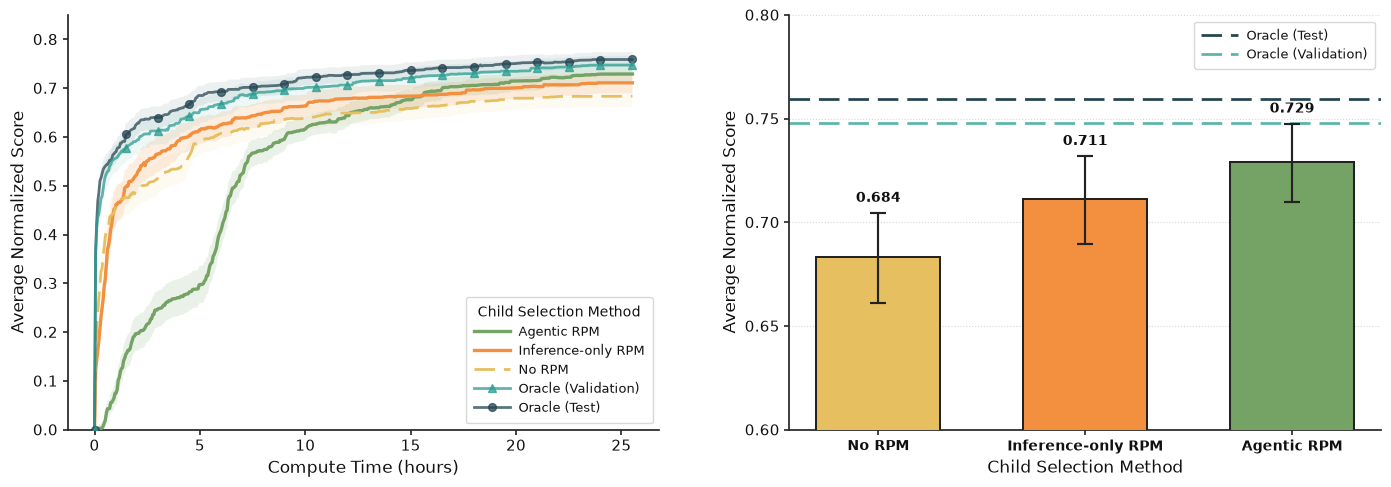

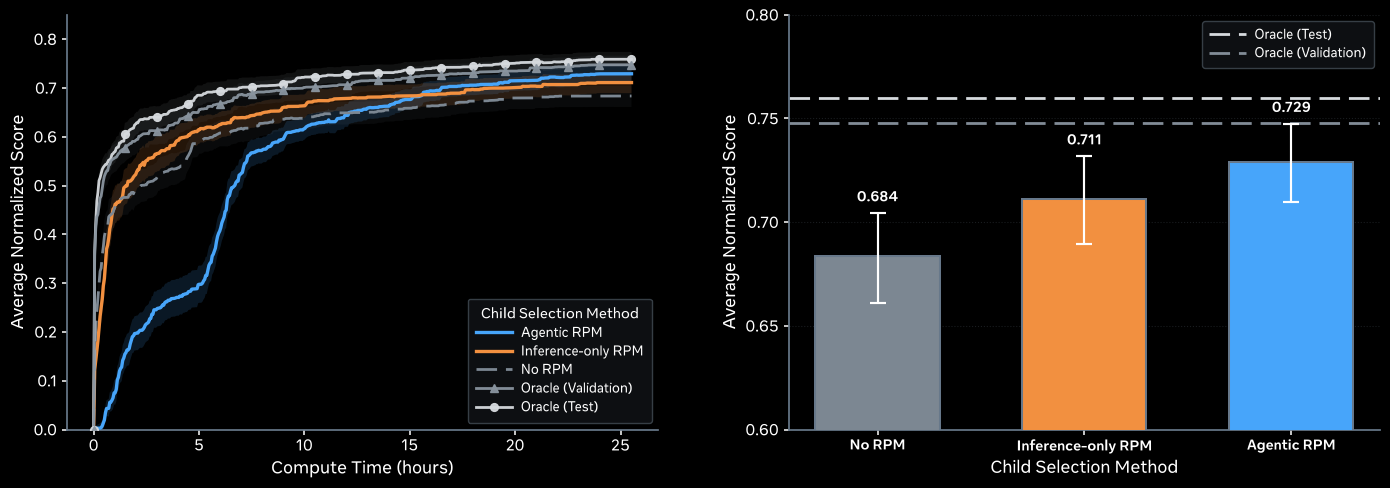

Saved:
  /Users/balomari/projects/RPMs/animation/graphs/figure2_recreated_light.png
  /Users/balomari/projects/RPMs/animation/graphs/figure2_recreated_light.pdf
  /Users/balomari/projects/RPMs/animation/graphs/figure2_recreated_dark.png
  /Users/balomari/projects/RPMs/animation/graphs/figure2_recreated_dark.pdf


In [4]:
LIGHT_PNG = OUTPUT_DIR / 'figure2_recreated_light.png'
LIGHT_PDF = OUTPUT_DIR / 'figure2_recreated_light.pdf'
DARK_PNG = OUTPUT_DIR / 'figure2_recreated_dark.png'
DARK_PDF = OUTPUT_DIR / 'figure2_recreated_dark.pdf'

light_figure = make_figure2(LIGHT_THEME)
light_save_options = {'facecolor': LIGHT_THEME['figure_bg'], 'bbox_inches': 'tight', 'pad_inches': 0.06}
light_figure.savefig(LIGHT_PNG, dpi=240, **light_save_options)
light_figure.savefig(LIGHT_PDF, **light_save_options)
plt.show()

dark_figure = make_figure2(DARK_THEME)
dark_save_options = {'facecolor': DARK_THEME['figure_bg'], 'bbox_inches': 'tight', 'pad_inches': 0.06}
dark_figure.savefig(DARK_PNG, dpi=240, **dark_save_options)
dark_figure.savefig(DARK_PDF, **dark_save_options)
plt.show()

print('Saved:')
for output in (LIGHT_PNG, LIGHT_PDF, DARK_PNG, DARK_PDF):
    print(f'  {output}')